In [1]:
import yaml
import os, sys, importlib, math
import pandas as pd
import numpy as np
import torch
sys.path.append("../src/tuning/")

In [2]:
from algo import template, gw
from chessIntegration import chessSpec
import texel
importlib.reload(template)
importlib.reload(gw)
importlib.reload(chessSpec)

__init__.py got invoked at: /mnt/c/Users/iTreek/Documents/Formation/Zig_adventures/chess/test/../src/tuning/algo/__init__.py
__init__.py got invoked at: /mnt/c/Users/iTreek/Documents/Formation/Zig_adventures/chess/test/../src/tuning/chessIntegration/__init__.py


<module 'chessIntegration.chessSpec' from '/mnt/c/Users/iTreek/Documents/Formation/Zig_adventures/chess/test/../src/tuning/chessIntegration/chessSpec.py'>

In [7]:
importlib.reload(texel)

<module 'texel' from '/mnt/c/Users/iTreek/Documents/Formation/Zig_adventures/chess/test/../src/tuning/texel.py'>

In [8]:
import torch.nn as nn
import sklearn


In [9]:
a = texel.texelWeights()
a.pushArray(chessSpec.simplePieceCount, texel.countPawn_idx)
a.pushArray([chessSpec.newWeight_0_bis[chessSpec.mobility_idx]], texel.mobility_idx)
a.pushArray([chessSpec.newWeight_0_bis[chessSpec.structureProtection_idx]], texel.structureProtection_idx)
a.pushArray(chessSpec.newWeight_0_bis[chessSpec.isolatedPawnScore_idx:chessSpec.passedPawnScore_idx+1], texel.isolatedPawnScore_idx)
a.pushArray(chessSpec.newWeight_0_bis[chessSpec.safetyKnight_idx:chessSpec.safetyQueen_idx+1], texel.safetyKnight_idx )
a.divide(100)

 [0.01, 0.03, 0.03, 0.05, 0.09] [0.01] [0.03] [0.95, -0.03, 0.18] [-0.0, 0.87, 0.2, 0.11]

In [ ]:
path = "../logs/test_weights_int_all.csv"
#def training_loop(path: str, pos_per_epoch: int, epoch: int, model: nn.Module, freq_pos_change: int = 4):
model = texel.texelNet(n_weights = texel.total_idx)
n_pos = 200_000
opt: texel.trainingOptions = texel.trainingOptions(
        path = path, 
        pos_per_epoch = n_pos,
        epoch = 256,
        tuneCfg = texel.tuneConfig(
            tuneCount = False, 
            tuneMobility = False, 
            tuneStructure = False, 
            tunePawnStructure = False, 
            tunePSQT = True, 
            tuneSafety = False), 
        initialWeights=a)

texel.training_loop(opt, model = model, freq_pos_change=4, fileSize = 9999740, batch_size=256)

[DEBUG] training_loop: 9999740 coeffs found
Epoch: 0: loss = 0.2092888355255127
Epoch: 10: loss = 0.3017144203186035


In [26]:
texel.printTensorWeight(model.W_mg.weight.detach().numpy()[0])

pawnCount: 1.0, bishopCount: 3.0, knightCount: 3.0, rookCount: 5.0, queenCount: 9.0 
moveCount: -0.009999999776482582, structureProtection: 0.019999999552965164
isolatedScore: -0.009999999776482582, stackedScore: 0.20000000298023224, passedScore: 0.20000000298023224
pawnArr: 
0.011500000022351742, 0.03229999914765358, -0.015200000256299973, -0.01759999990463257, -0.006099999882280827, 0.032600000500679016, 0.008500000461935997, -0.017500000074505806, 
0.5835999846458435, 0.6255000233650208, 0.5253000259399414, -0.0925000011920929, 0.5217999815940857, 0.7150999903678894, 0.6503000259399414, 0.6825000047683716, 
0.5436000227928162, 0.2621000111103058, 0.13269999623298645, 0.19709999859333038, 0.21310000121593475, 0.1762000024318695, 0.41589999198913574, 0.4162999987602234, 
-0.07090000063180923, -0.08349999785423279, -0.1680999994277954, -0.32499998807907104, -0.2467000037431717, -0.23119999468326569, -0.15929999947547913, -0.07069999724626541, 
-0.17730000615119934, -0.2799000144004822,

In [27]:
texel.printTensorWeight(model.W_eg.weight.detach().numpy()[0])

pawnCount: 1.0, bishopCount: 3.0, knightCount: 3.0, rookCount: 5.0, queenCount: 9.0 
moveCount: -0.009999999776482582, structureProtection: 0.019999999552965164
isolatedScore: -0.009999999776482582, stackedScore: 0.20000000298023224, passedScore: 0.20000000298023224
pawnArr: 
-0.02710000053048134, -0.024299999698996544, -0.019700000062584877, -0.049800001084804535, -0.03370000049471855, -0.04639999940991402, -0.019600000232458115, -0.008700000122189522, 
0.7129999995231628, 0.31690001487731934, 0.6601999998092651, 1.166100025177002, 0.7953000068664551, 0.1890999972820282, 0.14239999651908875, 0.9837999939918518, 
-1.2230000495910645, -0.42669999599456787, -0.3391000032424927, -0.38999998569488525, -0.20010000467300415, -0.47859999537467957, -0.8371000289916992, -0.9259999990463257, 
-0.987500011920929, -0.8379999995231628, -0.7063999772071838, -0.5831000208854675, -0.661300003528595, -0.7379999756813049, -0.8544999957084656, -0.9545000195503235, 
-0.9375, -0.8823999762535095, -0.803799

In [37]:
importlib.reload(texel)

<module 'texel' from '/mnt/c/Users/iTreek/Documents/Formation/Zig_adventures/chess/test/../src/tuning/texel.py'>

In [ ]:
import time

In [ ]:
texel.saveModelWeightToFile(path = f"test_{int(time.time())}.winfo",  model = model)

In [4]:
path = "../logs/test_weights_int_all.csv"
#def training_loop(path: str, pos_per_epoch: int, epoch: int, model: nn.Module, freq_pos_change: int = 4):
model = texel.texelNet(n_weights = 399)
n_pos = 200_000
texel.training_loop(path = path, pos_per_epoch=n_pos, epoch=256, model = model, freq_pos_change=4, fileSize = 9999740, batch_size=128)

[DEBUG] training_loop: 9999740 coeffs found
Epoch: 0: loss = 0.13491231203079224
Epoch: 10: loss = 0.12107735127210617
Epoch: 20: loss = 0.11465266346931458
Epoch: 30: loss = 0.11285767704248428
Epoch: 40: loss = 0.11111404746770859
Epoch: 50: loss = 0.1113070547580719
Epoch: 60: loss = 0.11244212836027145
Epoch: 70: loss = 0.11246014386415482
Epoch: 80: loss = 0.1115327849984169
Epoch: 90: loss = 0.11138298362493515
Epoch: 100: loss = 0.11126890033483505
Epoch: 110: loss = 0.11097348481416702
Epoch: 120: loss = 0.11080969125032425
Epoch: 130: loss = 0.11058463156223297
Epoch: 140: loss = 0.11036299169063568
Epoch: 150: loss = 0.11011683940887451
Epoch: 160: loss = 0.10987650603055954
Epoch: 170: loss = 0.10963510721921921
Epoch: 180: loss = 0.10940046608448029
Epoch: 190: loss = 0.10917310416698456
Epoch: 200: loss = 0.10925225913524628
Epoch: 210: loss = 0.10874718427658081
Epoch: 220: loss = 0.10854499042034149
Epoch: 230: loss = 0.1083555519580841
Epoch: 240: loss = 0.1081750169396

In [27]:
importlib.reload(texel)

<module 'texel' from '/mnt/c/Users/iTreek/Documents/Formation/Zig_adventures/chess/test/../src/tuning/texel.py'>

In [28]:
texel.printTensorWeight(model.W_eg.weight.detach().numpy()[0], True)

pawnCount: 0.23529860377311707, bishopCount: 0.7967561483383179, knightCount: 0.7441341876983643, rookCount: 1.1927363872528076, queenCount: 2.4444518089294434 
moveCount: -0.0099063441157341, structureProtection: 0.021880371496081352
isolatedScore: -0.09546655416488647, stackedScore: -0.026617757976055145, passedScore: -0.10850785672664642
pawnArr: 
0, 0, 0, 0, 0, 0, 0, 0, 
110, 85, 86, 120, 105, 79, 83, 113, 
-24, 41, 47, 33, 52, 36, 12, 0, 
-6, 4, 10, 20, 13, 8, 3, -5, 
-4, -2, -6, 1, 1, -4, -1, -8, 
-5, -8, -8, -1, -3, -12, -8, -7, 
-7, -4, -7, -8, -10, -5, -8, -10, 
0, 0, 0, 0, 0, 0, 0, 0, 
bishopArr: 
0, 88, 32, 27, 70, 50, 15, 66, 
37, 50, 40, 63, 37, 59, 33, 41, 
42, 36, 79, 52, 60, 50, 51, 54, 
27, 37, 34, 58, 47, 42, 33, 46, 
31, 26, 29, 45, 42, 37, 33, 39, 
38, 30, 30, 38, 28, 31, 31, 38, 
25, 35, 31, 24, 32, 30, 39, 36, 
22, 33, 20, 15, 23, 26, 36, 46, 
knightArr: 
-50, 9, 3, 34, 80, -45, 6, -34, 
31, 6, 49, 59, 13, 34, -14, 20, 
35, 30, 59, 59, 57, 60, 51, 18, 
32, 27, 36,

In [29]:
texel.printTensorWeight(model.W_mg.weight.detach().numpy()[0], True)

pawnCount: 0.4611072242259979, bishopCount: 0.7456916570663452, knightCount: 0.9864108562469482, rookCount: 1.5362528562545776, queenCount: 2.351408004760742 
moveCount: 0.007389955222606659, structureProtection: 0.02819824405014515
isolatedScore: 0.015992512926459312, stackedScore: -0.08590032905340195, passedScore: 0.11567986011505127
pawnArr: 
0, 0, 0, 0, 0, 0, 0, 0, 
83, 82, 78, 44, 79, 86, 84, 94, 
77, 59, 46, 54, 51, 47, 66, 69, 
29, 38, 28, 14, 20, 22, 29, 29, 
19, 17, 13, 14, 16, 13, 19, 18, 
14, 14, 20, 24, 16, 18, 19, 11, 
24, 19, 29, 19, 16, 27, 25, 16, 
0, 0, 0, 0, 0, 0, 0, 0, 
bishopArr: 
80, 67, 71, 74, 58, 70, 69, 43, 
78, 68, 85, 71, 80, 61, 66, 63, 
74, 81, 62, 83, 72, 83, 75, 65, 
68, 74, 79, 68, 82, 74, 90, 60, 
49, 72, 77, 73, 76, 73, 67, 62, 
46, 63, 73, 71, 78, 71, 72, 61, 
72, 57, 47, 59, 59, 42, 65, 27, 
47, 12, 51, 49, 48, 44, 61, 51, 
knightArr: 
36, 66, 64, 43, 74, 87, 84, 62, 
37, 51, 57, 68, 88, 68, 63, 52, 
41, 69, 67, 72, 66, 76, 49, 55, 
39, 63, 77, 79, 

In [7]:
texel.printTensorWeight(model.W_eg.weight.detach().numpy()[0])

pawnCount: 0.23529860377311707, bishopCount: 0.7967561483383179, knightCount: 0.7441341876983643, rookCount: 1.1927363872528076, queenCount: 2.4444518089294434 
moveCount: -0.0099063441157341, structureProtection: 0.021880371496081352
isolatedScore: -0.09546655416488647, stackedScore: -0.026617757976055145, passedScore: -0.10850785672664642
pawnArr: 
0.0, -0.0, -0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 
1.104699969291687, 0.8514000177383423, 0.8608999848365784, 1.2005000114440918, 1.0578999519348145, 0.7982000112533569, 0.8325999975204468, 1.1333999633789062, 
-0.2402999997138977, 0.4113999903202057, 0.47540000081062317, 0.33799999952316284, 0.527899980545044, 0.3601999878883362, 0.12479999661445618, 0.005400000140070915, 
-0.06960000097751617, 0.04270000010728836, 0.10499999672174454, 0.20579999685287476, 0.13689999282360077, 0.08250000327825546, 0.03869999945163727, -0.0560000017285347, 
-0.040800001472234726, -0.02590000070631504, -0.06289999932050705, 0.010599999688565731, 0.01360000018030405

In [3]:
path = "../logs/test_weights.csv"
df = texel.loadTexelWeight(path, n_pos = 10_000, dtype = np.float16)
x, y = texel.extractXYFromDF(df)
#x[:, -2:]*=100

In [8]:
x_train, x_test, y_train, y_test = sklearn.model_selection.train_test_split(x, y, test_size=0.2, random_state=42)
n_weights = x.shape[1] - 2 # -2 for the 2 factors added
del x, y


In [9]:
torch_x_train = torch.from_numpy(x_train).float()
torch_y_train = torch.from_numpy(y_train.reshape(-1, 1)).float()

torch_x_test = torch.from_numpy(x_test).float()
torch_y_test = torch.from_numpy(y_test.reshape(-1, 1)).float()
best_weights = [None, None]
best_loss_test = float("inf")
best_epoch = 0


In [10]:
batch_size = 32
amount_batch = math.ceil(len(torch_x_train) / batch_size)
print(amount_batch)

250


In [11]:
torch_x_train.dtype

torch.float32

In [ ]:
batch_size = 128
amount_batch = math.ceil(len(torch_x_train) / batch_size)
print(amount_batch)
model = texel.texelNet(n_weights = n_weights)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=0.0001)
# scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=128, gamma=0.80)
for epoch in range(8192):
    optimizer.zero_grad()  # Zero the gradients
    for batch in range(amount_batch):
        outputs = model(torch_x_train[batch*batch_size:(batch + 1)*batch_size])
        loss = criterion(outputs, torch_y_train[batch*batch_size:(batch + 1)*batch_size])
        loss.backward()  # Backward pass
    optimizer.step()  # Update the parameters

    # scheduler.step()
    outp_test = model(torch_x_test)
    loss_test = criterion(outp_test, torch_y_test)
    if (loss_test.item() < best_loss_test):
        best_weights[0] = np.copy(model.W_mg.weight.detach().numpy())
        best_weights[1] = np.copy(model.W_eg.weight.detach().numpy())
        best_loss_test = loss_test.item()
        best_epoch = epoch
    if (epoch % 10 == 0):
        print(f"Epoch: {epoch}: loss = {loss.item()}, loss_test: {loss_test.item()}")

63


In [ ]:
next(model.named_parameters())

('W_mg.weight',
 Parameter containing:
 tensor([[ 4.4602e-02,  2.3737e-02, -3.7719e-02, -3.9938e-02,  2.6681e-02,
           3.5593e-02,  3.5206e-02, -1.6445e-02,  4.0369e-02, -4.7975e-02,
          -9.8749e-03, -3.6465e-02, -3.2140e-02,  2.3025e-02, -3.9364e-02,
           1.6537e-02, -3.1166e-02, -2.1093e-02,  4.1625e-02, -6.1693e-03,
          -1.7567e-02,  4.2547e-02, -4.9955e-02, -4.7627e-02,  6.0621e-03,
           2.9100e-02,  4.1466e-02, -7.8062e-03, -6.5795e-03,  1.3830e-02,
          -4.6483e-02,  3.0426e-02,  3.6137e-02,  4.2065e-02,  2.2531e-02,
          -2.8749e-02,  1.1850e-02,  2.2889e-02, -3.4920e-02, -4.6444e-02,
          -4.9028e-02, -4.0071e-02, -2.6940e-02,  3.5428e-02,  1.6071e-02,
           2.3322e-03, -2.6704e-02,  3.0531e-02, -1.6525e-02, -4.5298e-02,
          -2.2987e-02,  4.8558e-02,  3.8496e-03,  2.5782e-02, -2.8538e-02,
           4.4194e-02, -1.7952e-02,  9.1897e-03, -2.2116e-02,  3.4380e-02,
          -1.5721e-02,  3.3597e-02,  1.9727e-02,  4.5400e-02,

In [28]:
params = model.named_parameters()
mg = next(params)

In [40]:
(torch.mul(mg[1].grad, mg[1].grad)).shape

torch.Size([1, 397])

In [52]:
type(mg[1][0])

torch.Tensor

In [8]:
totalPhase = 32
def computeMerge(score: int, phase: int):
    phase = int((phase * 256 + int(totalPhase/2)) / totalPhase)
    return int(((score * (256 - phase)) + score * phase) / 256)

In [9]:
computeMerge(16, 0)

16

In [10]:
import matplotlib.pyplot as plt

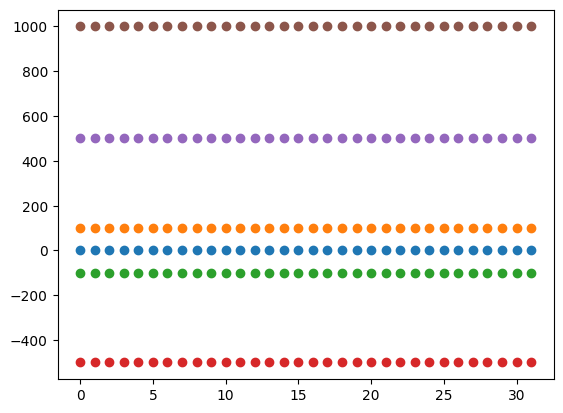

In [20]:
x = np.arange(0, 32)
scores = [0, 100, -100, -500, 500, 1000] 
fig, ax = plt.subplots()
for score in scores:   
    y = [computeMerge(score, e) for e in x]
    ax.scatter(x, y)